# AM115 Group Project 2: Library Seat-Release Simulation

This notebook builds a **stochastic agent-based simulation** of seat use in a university library and compares fixed and dynamic seat-release policies.

## Baseline assumptions

- 5,000 identical seats
- 12-hour day, updated once per minute
- Time-varying Poisson arrivals
- Study duration: Uniform(60, 360) minutes
- Temporary absence duration: Uniform(5, 65) minutes
- Students wait at most 30 minutes for a seat
- Returning students and new arrivals share a first-come, first-served queue

## Policies

Four fixed policies release a temporarily unoccupied seat after 15, 30, 45, or 60 minutes. A fifth **queue-and-occupancy dynamic policy** assigns a release threshold when the student leaves. The assigned threshold is locked for that absence.

## Literature-motivated welfare framework

The objective follows four ideas from queueing and service-operations research:

1. **Naor (1969):** social welfare combines the benefit of receiving service with waiting costs.
2. **Hassin and Haviv (2003):** welfare is aggregated across the actual customers affected by the queue.
3. **Kostami and Ward (2009):** waiting and abandonment should both enter the evaluation of systems with returning customers.
4. **Feldman and Segev (2022):** holding a service resource while others wait creates a congestion externality.

The numerical coefficients remain modeling assumptions and are therefore tested in sensitivity analysis.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import deque
from dataclasses import dataclass

SEAT_EMPTY = 0
SEAT_OCCUPIED = 1
SEAT_RESERVED = 2


In [2]:
@dataclass
class Student:
    remaining_study: int
    total_study: int
    leave_count: int
    max_leaves: int
    continuous_study: int
    seat_id: int | None
    away_remaining: int = 0
    away_elapsed: int = 0
    seat_released: bool = False
    assigned_release_limit: int | None = None


## Arrival process and policy definitions

The arrival rate varies during the day. The fixed policies use one threshold throughout the day. The dynamic policy assigns a threshold at the moment a student leaves, based on current queue pressure and physical occupancy.

In [3]:
def arrival_rate(minute, scale=1.0):
    """Time-varying mean arrivals per minute for a 12-hour day."""
    if minute < 120:       # 8:00-10:00
        base_rate = 14
    elif minute < 240:     # 10:00-12:00
        base_rate = 23
    elif minute < 420:     # 12:00-15:00
        base_rate = 29
    elif minute < 600:     # 15:00-18:00
        base_rate = 21
    else:                  # 18:00-20:00
        base_rate = 12

    return base_rate * scale


def max_leave_count(study_duration):
    """Maximum number of temporary absences based on planned study time."""
    if study_duration <= 120:
        return 1
    elif study_duration <= 240:
        return 2
    return 3


def fixed_policy_limit(policy):
    """Return the threshold for a fixed policy."""
    limits = {
        "15_min": 15,
        "30_min": 30,
        "45_min": 45,
        "60_min": 60
    }
    if policy not in limits:
        raise ValueError(f"Unknown fixed policy: {policy}")
    return limits[policy]


def dynamic_policy_limit(physical_occupancy_rate, queue_length):
    """Assign a release threshold using graded congestion pressure.

    The original dynamic rule switched to 15 minutes too frequently.
    This calibrated rule is more conservative:

    - 60 minutes when demand pressure is low;
    - 45 minutes under moderate occupancy or a small queue;
    - 30 minutes under substantial queue pressure;
    - 15 minutes only under severe congestion.

    Queue thresholds are scaled to the 5,000-seat baseline library.
    """
    # Severe congestion: use the shortest threshold only when the queue
    # is exceptionally long or the library is effectively full.
    if queue_length >= 500 or physical_occupancy_rate >= 0.995:
        return 15

    # High congestion: shorten the reservation period, but do not jump
    # immediately to the most aggressive policy.
    if queue_length >= 200 or physical_occupancy_rate >= 0.980:
        return 30

    # Moderate congestion: preserve some protection for returning students.
    if queue_length >= 50 or physical_occupancy_rate >= 0.930:
        return 45

    # Low congestion: there is little opportunity cost from reserving a seat.
    return 60


def policy_limit(policy, physical_occupancy_rate=None, queue_length=0):
    """Return the applicable threshold for either policy type."""
    if policy == "dynamic":
        if physical_occupancy_rate is None:
            return np.nan
        return dynamic_policy_limit(physical_occupancy_rate, queue_length)
    return fixed_policy_limit(policy)

In [4]:
def simulate_library(
    policy="30_min",
    n_seats=5000,
    total_minutes=720,
    arrival_scale=1.0,
    leave_probability=0.002,
    study_min=60,
    study_max=360,
    away_min=5,
    away_max=65,
    first_leave_after=30,
    repeat_leave_after=60,
    max_wait=30,
    seed=None
):
    rng = np.random.default_rng(seed)

    valid_policies = {"15_min", "30_min", "45_min", "60_min", "dynamic"}
    if policy not in valid_policies:
        raise ValueError(f"Unknown policy: {policy}")

    fixed_release_limit = (
        fixed_policy_limit(policy) if policy != "dynamic" else None
    )

    seat_state = np.zeros(n_seats, dtype=np.int8)
    seat_student = np.full(n_seats, -1, dtype=np.int64)
    empty_seats = list(range(n_seats - 1, -1, -1))

    students = {}
    occupied_ids = set()
    away_ids = set()
    waiting_queue = deque()
    next_student_id = 0

    total_arrivals = 0
    successful_new_arrivals = 0
    abandoned_new_arrivals = 0
    temporary_absence_events = 0
    policy_releases = 0
    return_events = 0
    displaced_returns = 0
    returning_abandonments = 0

    # Separate waiting costs prevent zero-wait arrivals from hiding the
    # experience of displaced returning students.
    new_waiting_times = []
    returning_waiting_times = []
    assigned_thresholds = []
    records = []

    def get_empty_seat():
        while empty_seats:
            seat_id = empty_seats.pop()
            if seat_state[seat_id] == SEAT_EMPTY:
                return seat_id
        return None

    def occupy_seat(student_id, seat_id):
        seat_state[seat_id] = SEAT_OCCUPIED
        seat_student[seat_id] = student_id
        student = students[student_id]
        student.seat_id = seat_id
        student.seat_released = False
        student.assigned_release_limit = None
        occupied_ids.add(student_id)

    def free_seat(seat_id):
        if seat_id is not None and seat_state[seat_id] != SEAT_EMPTY:
            seat_state[seat_id] = SEAT_EMPTY
            seat_student[seat_id] = -1
            empty_seats.append(seat_id)

    for minute in range(total_minutes):

        # 1. Update students who are currently studying
        for student_id in list(occupied_ids):
            student = students[student_id]
            student.remaining_study -= 1
            student.continuous_study += 1

            if student.remaining_study <= 0:
                free_seat(student.seat_id)
                occupied_ids.remove(student_id)
                del students[student_id]
                continue

            required_gap = (
                first_leave_after if student.leave_count == 0
                else repeat_leave_after
            )
            eligible_to_leave = (
                student.leave_count < student.max_leaves
                and student.continuous_study >= required_gap
            )

            if eligible_to_leave and rng.random() < leave_probability:
                physical_occupancy_rate = float(
                    np.count_nonzero(seat_state != SEAT_EMPTY) / n_seats
                )
                assigned_limit = (
                    dynamic_policy_limit(
                        physical_occupancy_rate,
                        queue_length=len(waiting_queue)
                    )
                    if policy == "dynamic"
                    else fixed_release_limit
                )

                student.leave_count += 1
                student.away_remaining = int(rng.integers(away_min, away_max + 1))
                student.away_elapsed = 0
                student.seat_released = False
                student.assigned_release_limit = int(assigned_limit)
                assigned_thresholds.append(int(assigned_limit))

                seat_state[student.seat_id] = SEAT_RESERVED
                occupied_ids.remove(student_id)
                away_ids.add(student_id)
                temporary_absence_events += 1

        # 2. Update temporarily absent students
        for student_id in list(away_ids):
            student = students[student_id]
            student.away_remaining -= 1
            student.away_elapsed += 1

            if (
                not student.seat_released
                and student.away_elapsed >= student.assigned_release_limit
            ):
                free_seat(student.seat_id)
                student.seat_id = None
                student.seat_released = True
                policy_releases += 1

            if student.away_remaining <= 0:
                away_ids.remove(student_id)
                student.continuous_study = 0
                student.away_elapsed = 0
                return_events += 1

                if student.seat_released:
                    displaced_returns += 1
                    waiting_queue.append((student_id, "returning", minute))
                else:
                    seat_state[student.seat_id] = SEAT_OCCUPIED
                    occupied_ids.add(student_id)

        # 3. Generate new arrivals
        arrivals = int(rng.poisson(arrival_rate(minute, scale=arrival_scale)))
        total_arrivals += arrivals

        for _ in range(arrivals):
            study_duration = int(rng.integers(study_min, study_max + 1))
            students[next_student_id] = Student(
                remaining_study=study_duration,
                total_study=study_duration,
                leave_count=0,
                max_leaves=max_leave_count(study_duration),
                continuous_study=0,
                seat_id=None
            )
            waiting_queue.append((next_student_id, "new", minute))
            next_student_id += 1

        # 4. Students who reach the maximum wait abandon the queue
        while waiting_queue and minute - waiting_queue[0][2] >= max_wait:
            student_id, searcher_type, start_time = waiting_queue.popleft()
            if searcher_type == "new":
                new_waiting_times.append(max_wait)
                abandoned_new_arrivals += 1
            else:
                returning_waiting_times.append(max_wait)
                returning_abandonments += 1
            if student_id in students:
                del students[student_id]

        # 5. Assign available seats using first-come, first-served
        while waiting_queue:
            seat_id = get_empty_seat()
            if seat_id is None:
                break
            student_id, searcher_type, start_time = waiting_queue.popleft()
            wait_duration = minute - start_time
            occupy_seat(student_id, seat_id)
            if searcher_type == "new":
                new_waiting_times.append(wait_duration)
                successful_new_arrivals += 1
            else:
                returning_waiting_times.append(wait_duration)

        # 6. Record the system state
        empty_count = int(np.sum(seat_state == SEAT_EMPTY))
        occupied_count = int(np.sum(seat_state == SEAT_OCCUPIED))
        reserved_count = int(np.sum(seat_state == SEAT_RESERVED))

        records.append({
            "minute": minute,
            "empty": empty_count,
            "occupied": occupied_count,
            "reserved": reserved_count,
            "queue_length": len(waiting_queue),
            "physical_occupancy_rate": (occupied_count + reserved_count) / n_seats,
            "actual_utilization_rate": occupied_count / n_seats,
            "reserved_unoccupied_rate": reserved_count / n_seats
        })

    # Treat unresolved end-of-day searches as censored at their observed wait,
    # capped by max_wait. They contribute to waiting cost but are not labelled
    # as abandonments unless they actually reached max_wait.
    while waiting_queue:
        student_id, searcher_type, start_time = waiting_queue.popleft()
        final_wait = max(min(total_minutes - start_time, max_wait), 0)
        if searcher_type == "new":
            new_waiting_times.append(final_wait)
            if final_wait >= max_wait:
                abandoned_new_arrivals += 1
        else:
            returning_waiting_times.append(final_wait)
            if final_wait >= max_wait:
                returning_abandonments += 1

    history = pd.DataFrame(records)

    mean_new_waiting_time = (
        float(np.mean(new_waiting_times)) if new_waiting_times else 0.0
    )
    mean_returning_waiting_time = (
        float(np.mean(returning_waiting_times))
        if returning_waiting_times else 0.0
    )

    R = history["actual_utilization_rate"].mean()

    # Naor (1969) and Hassin & Haviv (2003): receiving service creates
    # benefit, while waiting creates a cost. Abandoning students receive no
    # service benefit and still contribute their observed waiting time.
    D_N = (
        min(sum(new_waiting_times) / (total_arrivals * max_wait), 1.0)
        if total_arrivals > 0 else 0.0
    )
    new_service_rate = (
        successful_new_arrivals / total_arrivals
        if total_arrivals > 0 else 0.0
    )
    U_N = float(np.clip(new_service_rate - D_N, 0.0, 1.0))

    # Kostami & Ward (2009): returning customers face both waiting and
    # abandonment costs. Returns that keep their original seat have zero wait.
    D_R = (
        min(sum(returning_waiting_times) / (return_events * max_wait), 1.0)
        if return_events > 0 else 0.0
    )
    A_R = (
        returning_abandonments / return_events
        if return_events > 0 else 0.0
    )
    U_R = float(np.clip((1 - A_R) - D_R, 0.0, 1.0))

    # Population-weighted average welfare. This prevents a small subgroup from
    # receiving a fixed, disproportionate influence on the objective.
    total_service_events = total_arrivals + return_events
    service_welfare = (
        (total_arrivals * U_N + return_events * U_R) / total_service_events
        if total_service_events > 0 else 0.0
    )

    # Feldman & Segev (2022): a held resource creates a congestion externality
    # when other customers are waiting. min(E_t, Q_t) is the waiting demand that
    # could potentially have been served by reserved-but-empty seats.
    total_queue_pressure = float(history["queue_length"].sum())
    pressure_idle_numerator = float(
        np.minimum(history["reserved"], history["queue_length"]).sum()
    )
    I_P = (
        pressure_idle_numerator / total_queue_pressure
        if total_queue_pressure > 0 else 0.0
    )

    # Descriptive outcomes retained for interpretation.
    A = abandoned_new_arrivals / total_arrivals if total_arrivals > 0 else 0.0
    L = displaced_returns / return_events if return_events > 0 else 0.0
    I = history["reserved_unoccupied_rate"].mean()

    baseline_utility = (
        0.40 * R
        + 0.50 * service_welfare
        + 0.10 * (1 - I_P)
    )

    threshold_counts = {
        threshold: assigned_thresholds.count(threshold)
        for threshold in (15, 30, 45, 60)
    }

    summary = {
        "policy": policy,
        "release_threshold": fixed_release_limit if policy != "dynamic" else np.nan,
        "mean_assigned_release_threshold": (
            float(np.mean(assigned_thresholds)) if assigned_thresholds else np.nan
        ),
        "share_threshold_15": threshold_counts[15] / len(assigned_thresholds) if assigned_thresholds else 0.0,
        "share_threshold_30": threshold_counts[30] / len(assigned_thresholds) if assigned_thresholds else 0.0,
        "share_threshold_45": threshold_counts[45] / len(assigned_thresholds) if assigned_thresholds else 0.0,
        "share_threshold_60": threshold_counts[60] / len(assigned_thresholds) if assigned_thresholds else 0.0,
        "total_arrivals": total_arrivals,
        "successful_new_arrivals": successful_new_arrivals,
        "abandoned_new_arrivals": abandoned_new_arrivals,
        "new_arrival_abandonment_rate": A,
        "mean_new_waiting_time": mean_new_waiting_time,
        "normalized_new_wait_cost": D_N,
        "new_student_welfare": U_N,
        "mean_returning_waiting_time": mean_returning_waiting_time,
        "returning_wait_cost": D_R,
        "returning_student_welfare": U_R,
        "service_welfare": service_welfare,
        "pressure_idle_externality": I_P,
        "returning_abandonments": returning_abandonments,
        "returning_abandonment_rate": (
            returning_abandonments / return_events if return_events > 0 else 0.0
        ),
        "productive_utilization": R,
        "displacement_rate": L,
        "reserved_unoccupied_rate": I,
        "temporary_absence_events": temporary_absence_events,
        "policy_releases": policy_releases,
        "return_events": return_events,
        "displaced_returns": displaced_returns,
        "peak_queue_length": int(history["queue_length"].max()),
        "baseline_utility": baseline_utility
    }

    return history, summary

In [5]:

history, summary = simulate_library(
    policy="30_min",
    seed=123
)

pd.Series(summary)


policy                                30_min
release_threshold                         30
mean_assigned_release_threshold         30.0
share_threshold_15                       0.0
share_threshold_30                       1.0
share_threshold_45                       0.0
share_threshold_60                       0.0
total_arrivals                         14870
successful_new_arrivals                14685
abandoned_new_arrivals                   185
new_arrival_abandonment_rate        0.012441
mean_new_waiting_time               8.690585
normalized_new_wait_cost            0.289686
new_student_welfare                 0.697873
mean_returning_waiting_time        11.284862
returning_wait_cost                 0.221272
returning_student_welfare           0.778728
service_welfare                     0.714004
pressure_idle_externality           0.326984
returning_abandonments                     0
returning_abandonment_rate               0.0
productive_utilization              0.727505
displaceme

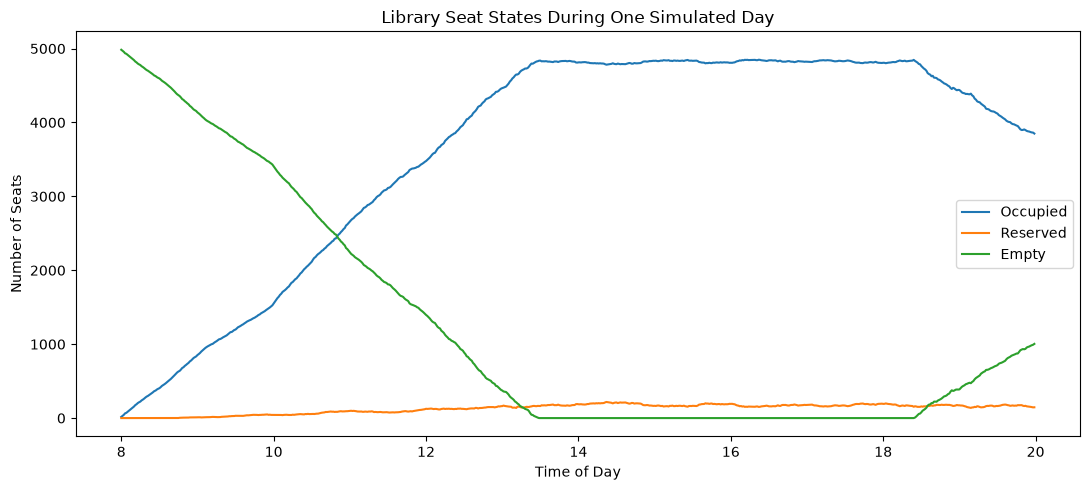

In [6]:

time_in_hours = 8 + history["minute"] / 60

plt.figure(figsize=(11, 5))
plt.plot(time_in_hours, history["occupied"], label="Occupied")
plt.plot(time_in_hours, history["reserved"], label="Reserved")
plt.plot(time_in_hours, history["empty"], label="Empty")
plt.xlabel("Time of Day")
plt.ylabel("Number of Seats")
plt.title("Library Seat States During One Simulated Day")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
FIXED_POLICIES = ("15_min", "30_min", "45_min", "60_min")
POLICIES = FIXED_POLICIES + ("dynamic",)

POLICY_NAMES = {
    "15_min": "15 minutes",
    "30_min": "30 minutes",
    "45_min": "45 minutes",
    "60_min": "60 minutes",
    "dynamic": "Dynamic policy"
}

POLICY_ORDER = {policy: i for i, policy in enumerate(POLICIES)}


def compare_policies(
    policies=POLICIES,
    replications=50,
    base_seed=1000,
    **simulation_parameters
):
    rows = []
    for replication in range(replications):
        simulation_seed = base_seed + replication
        for policy in policies:
            _, summary = simulate_library(
                policy=policy,
                seed=simulation_seed,
                **simulation_parameters
            )
            summary["replication"] = replication
            rows.append(summary)
    return pd.DataFrame(rows)


results = compare_policies(replications=50)
results.head()


,policy,release_threshold,mean_assigned_release_threshold,share_threshold_15,share_threshold_30,share_threshold_45,share_threshold_60,total_arrivals,successful_new_arrivals,abandoned_new_arrivals,...,productive_utilization,displacement_rate,reserved_unoccupied_rate,temporary_absence_events,policy_releases,return_events,displaced_returns,peak_queue_length,baseline_utility,replication
0,15_min,15.0,15.000000,1.000000,0.000000,0.000000,0.000000,14661,14661,0,...,0.734646,0.836513,0.014416,3993,3300,3774,3157,766,0.752998,0
1,30_min,30.0,30.000000,0.000000,1.000000,0.000000,0.000000,14869,14706,163,...,0.730805,0.579931,0.025746,3977,2250,3747,2173,936,0.708453,0
2,45_min,45.0,45.000000,0.000000,0.000000,1.000000,0.000000,14999,14769,230,...,0.729940,0.340568,0.032801,3968,1298,3732,1271,941,0.686500,0
3,60_min,60.0,60.000000,0.000000,0.000000,0.000000,1.000000,14925,14541,384,...,0.722746,0.087856,0.035647,3940,328,3722,327,927,0.700278,0
4,dynamic,NaN,30.395916,0.610807,0.037849,0.065488,0.285857,14943,14879,64,...,0.740439,0.604725,0.022000,4016,2310,3767,2278,902,0.710621,0


In [8]:
policy_summary = (
    results.groupby("policy")
    .agg(
        release_threshold=("release_threshold", "first"),
        mean_assigned_release_threshold=("mean_assigned_release_threshold", "mean"),
        mean_productive_utilization=("productive_utilization", "mean"),
        mean_new_waiting_time=("mean_new_waiting_time", "mean"),
        mean_normalized_new_wait_cost=("normalized_new_wait_cost", "mean"),
        mean_new_student_welfare=("new_student_welfare", "mean"),
        mean_abandonment_rate=("new_arrival_abandonment_rate", "mean"),
        mean_returning_waiting_time=("mean_returning_waiting_time", "mean"),
        mean_returning_wait_cost=("returning_wait_cost", "mean"),
        mean_returning_student_welfare=("returning_student_welfare", "mean"),
        mean_service_welfare=("service_welfare", "mean"),
        mean_pressure_idle_externality=("pressure_idle_externality", "mean"),
        mean_returning_abandonment_rate=("returning_abandonment_rate", "mean"),
        mean_displacement_rate=("displacement_rate", "mean"),
        mean_reserved_unoccupied_rate=("reserved_unoccupied_rate", "mean"),
        mean_policy_releases=("policy_releases", "mean"),
        mean_peak_queue_length=("peak_queue_length", "mean"),
        mean_utility=("baseline_utility", "mean"),
        utility_standard_error=(
            "baseline_utility",
            lambda x: x.std(ddof=1) / np.sqrt(len(x))
        ),
        share_threshold_15=("share_threshold_15", "mean"),
        share_threshold_30=("share_threshold_30", "mean"),
        share_threshold_45=("share_threshold_45", "mean"),
        share_threshold_60=("share_threshold_60", "mean")
    )
    .reset_index()
)

policy_summary["policy_order"] = policy_summary["policy"].map(POLICY_ORDER)
policy_summary = policy_summary.sort_values("policy_order").set_index("policy")
policy_summary

,release_threshold,mean_assigned_release_threshold,mean_productive_utilization,mean_new_waiting_time,mean_normalized_new_wait_cost,mean_new_student_welfare,mean_abandonment_rate,mean_returning_waiting_time,mean_returning_wait_cost,mean_returning_student_welfare,...,mean_reserved_unoccupied_rate,mean_policy_releases,mean_peak_queue_length,mean_utility,utility_standard_error,share_threshold_15,share_threshold_30,share_threshold_45,share_threshold_60,policy_order
policy,,,,,,,,,,,,,,,,,,,,,
15_min,15.0,15.000000,0.738977,8.394562,0.279819,0.717591,0.002591,10.857570,0.300248,0.699752,...,0.014686,3333.98,831.68,0.733780,0.001900,1.000000,0.000000,0.000000,0.00000,0
30_min,30.0,30.000000,0.731496,9.371397,0.312380,0.676888,0.010733,12.078106,0.232054,0.767946,...,0.025971,2265.86,911.50,0.708333,0.001037,0.000000,1.000000,0.000000,0.00000,1
45_min,45.0,45.000000,0.726190,9.736266,0.324542,0.659292,0.016165,12.510949,0.138420,0.861580,...,0.032965,1275.90,907.52,0.698751,0.001179,0.000000,0.000000,1.000000,0.00000,2
60_min,60.0,60.000000,0.722877,9.869840,0.328995,0.648127,0.022878,12.676908,0.039216,0.960784,...,0.036104,350.86,892.90,0.696802,0.000975,0.000000,0.000000,0.000000,1.00000,3
dynamic,NaN,31.639577,0.738528,8.721179,0.290706,0.706736,0.002558,15.492939,0.302625,0.697375,...,0.022613,2258.50,835.50,0.727549,0.001875,0.577097,0.041662,0.076081,0.30516,4


In [9]:

optimal_baseline_policy = policy_summary["mean_utility"].idxmax()

print(
    "Baseline optimal policy:",
    POLICY_NAMES[optimal_baseline_policy]
)
print(
    "Estimated mean utility:",
    round(
        policy_summary.loc[
            optimal_baseline_policy,
            "mean_utility"
        ],
        4
    )
)


Baseline optimal policy: 15 minutes
Estimated mean utility: 0.7338


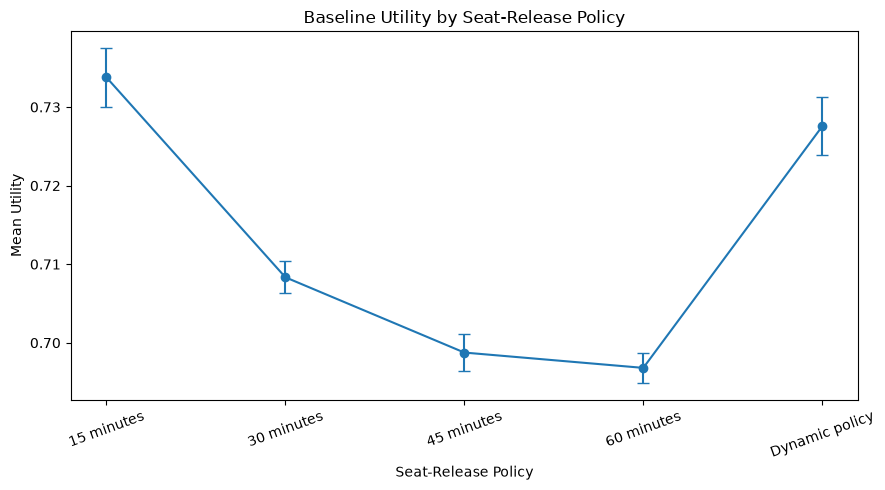

In [10]:
plot_data = policy_summary.reset_index()
x = np.arange(len(plot_data))

plt.figure(figsize=(9, 5))
plt.errorbar(
    x,
    plot_data["mean_utility"],
    yerr=1.96 * plot_data["utility_standard_error"],
    marker="o",
    capsize=4
)
plt.xlabel("Seat-Release Policy")
plt.ylabel("Mean Utility")
plt.title("Baseline Utility by Seat-Release Policy")
plt.xticks(x, [POLICY_NAMES[p] for p in plot_data["policy"]], rotation=20)
plt.tight_layout()
plt.show()


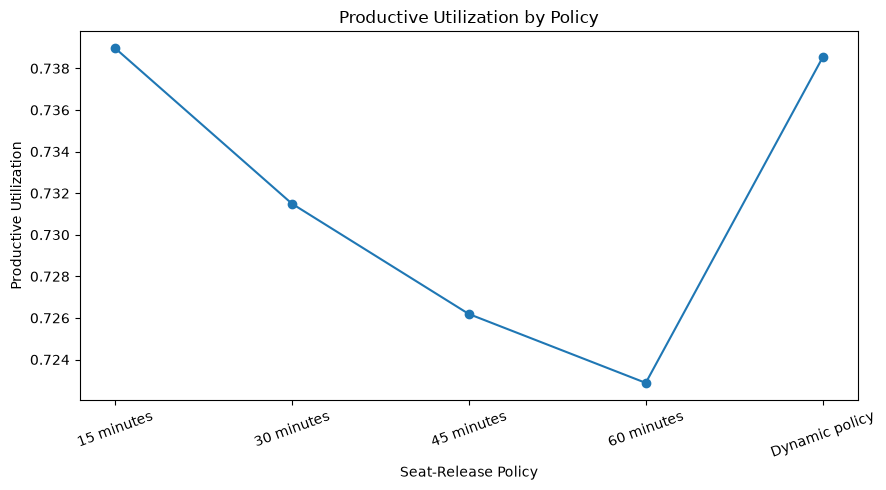

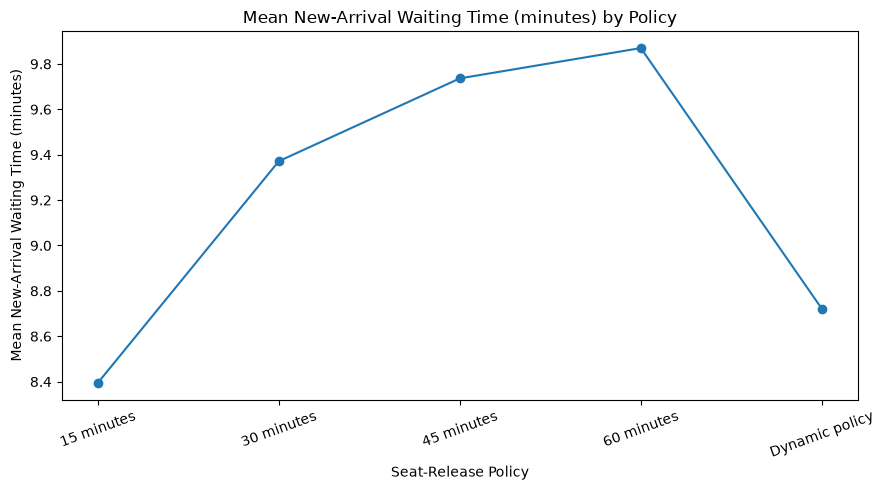

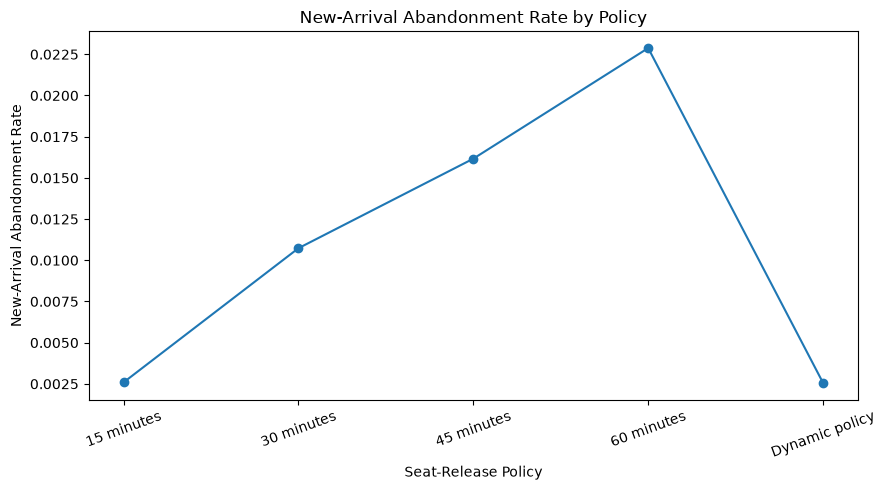

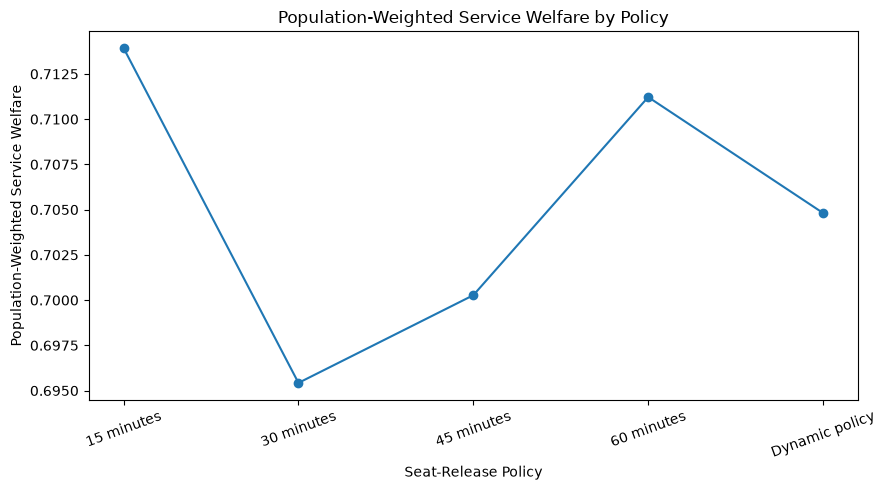

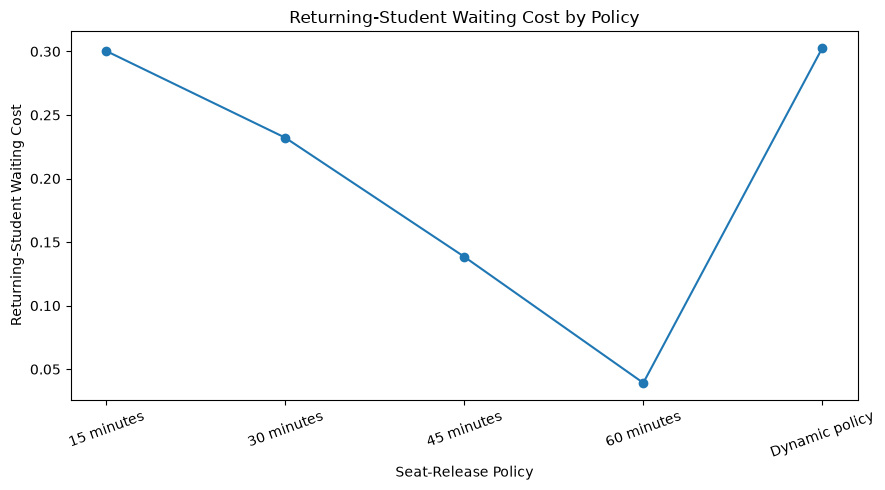

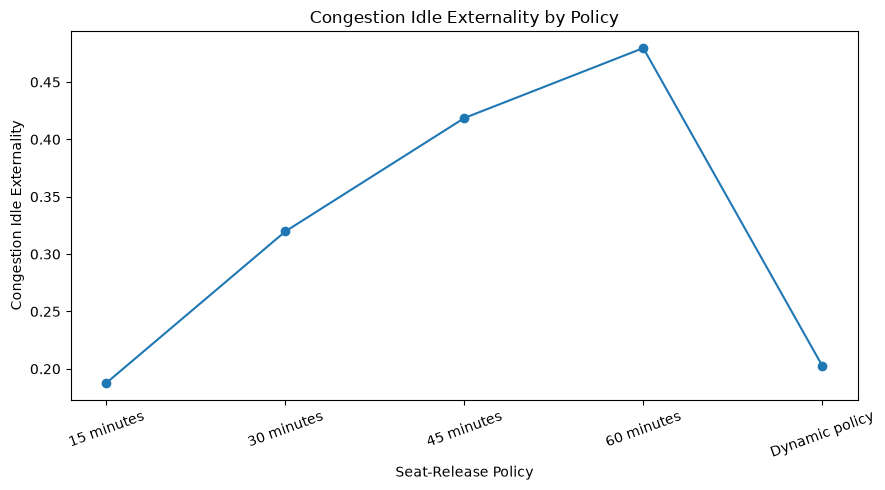

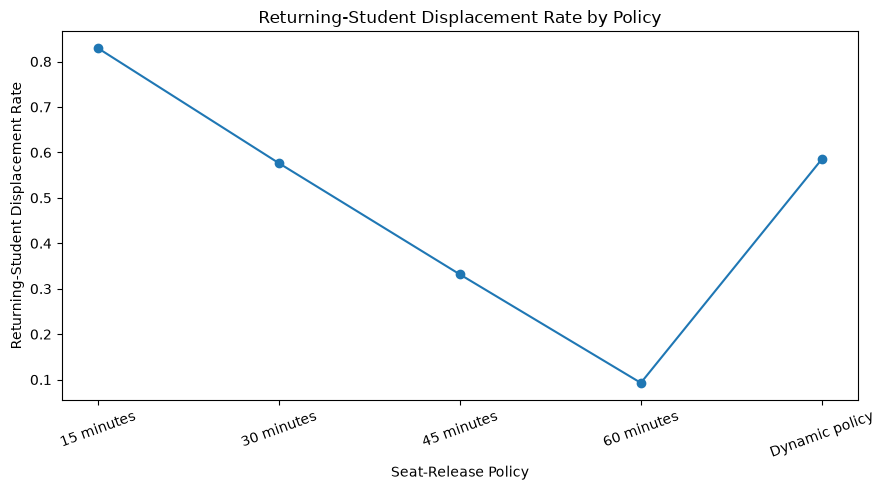

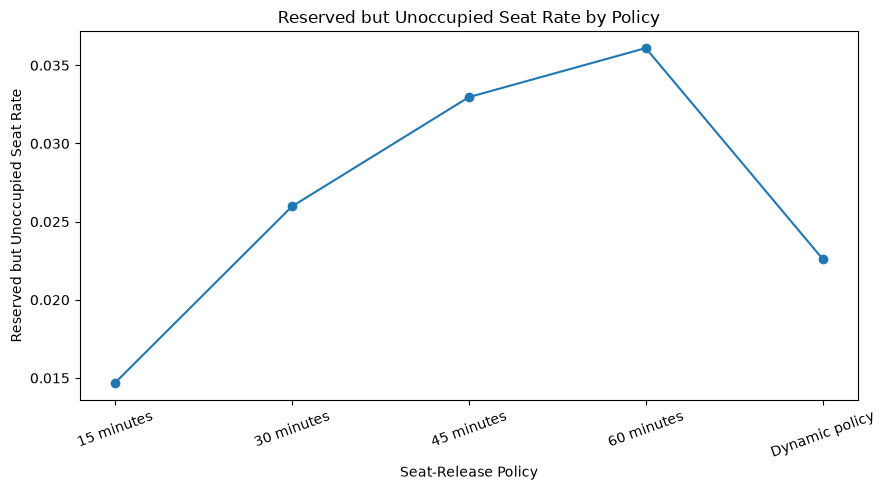

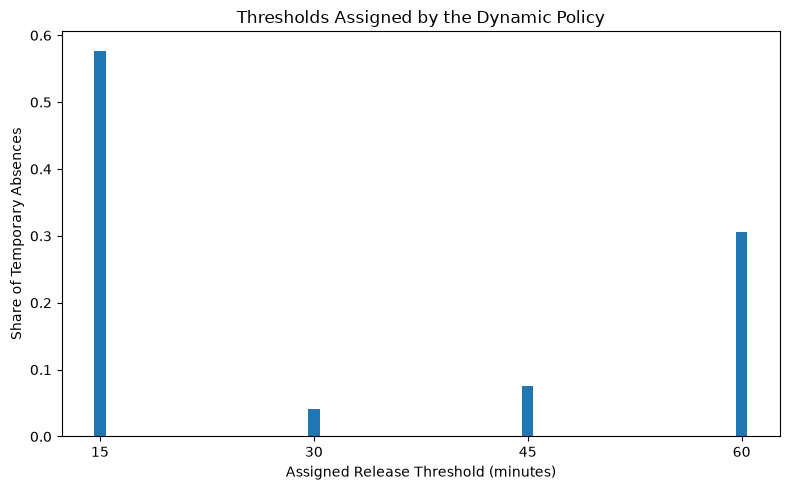

In [11]:
figures_to_plot = [
    ("mean_productive_utilization", "Productive Utilization"),
    ("mean_new_waiting_time", "Mean New-Arrival Waiting Time (minutes)"),
    ("mean_abandonment_rate", "New-Arrival Abandonment Rate"),
    ("mean_service_welfare", "Population-Weighted Service Welfare"),
    ("mean_returning_wait_cost", "Returning-Student Waiting Cost"),
    ("mean_pressure_idle_externality", "Congestion Idle Externality"),
    ("mean_displacement_rate", "Returning-Student Displacement Rate"),
    ("mean_reserved_unoccupied_rate", "Reserved but Unoccupied Seat Rate")
]

plot_data = policy_summary.reset_index()
x = np.arange(len(plot_data))

for column, title in figures_to_plot:
    plt.figure(figsize=(9, 5))
    plt.plot(x, plot_data[column], marker="o")
    plt.xlabel("Seat-Release Policy")
    plt.ylabel(title)
    plt.title(f"{title} by Policy")
    plt.xticks(x, [POLICY_NAMES[p] for p in plot_data["policy"]], rotation=20)
    plt.tight_layout()
    plt.show()

# Show how the dynamic policy distributes its assigned thresholds.
dynamic_distribution = policy_summary.loc["dynamic", [
    "share_threshold_15",
    "share_threshold_30",
    "share_threshold_45",
    "share_threshold_60"
]]

plt.figure(figsize=(8, 5))
plt.bar([15, 30, 45, 60], dynamic_distribution.values)
plt.xlabel("Assigned Release Threshold (minutes)")
plt.ylabel("Share of Temporary Absences")
plt.title("Thresholds Assigned by the Dynamic Policy")
plt.xticks([15, 30, 45, 60])
plt.tight_layout()
plt.show()

In [12]:
# Management-priority scenarios
#
# R       = productive utilization
# U_N     = welfare of new arrivals
# U_R     = welfare of returning students
# I       = avoidance of congestion-related idle-seat externality
#
# The weights in each scenario sum to 1. They are modeling assumptions used
# for sensitivity analysis rather than values prescribed by the literature.

MANAGEMENT_SCENARIOS = {
    "Balanced": {
        "R": 0.30,
        "U_N": 0.30,
        "U_R": 0.30,
        "I": 0.10
    },
    "Efficiency-focused": {
        "R": 0.55,
        "U_N": 0.20,
        "U_R": 0.10,
        "I": 0.15
    },
    "Access-focused": {
        "R": 0.25,
        "U_N": 0.50,
        "U_R": 0.15,
        "I": 0.10
    },
    "Return-protection": {
        "R": 0.20,
        "U_N": 0.15,
        "U_R": 0.55,
        "I": 0.10
    },
    "Congestion-focused": {
        "R": 0.25,
        "U_N": 0.25,
        "U_R": 0.15,
        "I": 0.35
    }
}


def validate_scenario_weights(weights, tolerance=1e-9):
    required = {"R", "U_N", "U_R", "I"}
    if set(weights) != required:
        raise ValueError(
            f"Scenario weights must contain exactly {sorted(required)}."
        )

    if any(value < 0 for value in weights.values()):
        raise ValueError("Scenario weights must be non-negative.")

    total = sum(weights.values())
    if abs(total - 1.0) > tolerance:
        raise ValueError(
            f"Scenario weights must sum to 1. Current sum: {total:.6f}"
        )


for scenario_weights in MANAGEMENT_SCENARIOS.values():
    validate_scenario_weights(scenario_weights)


def add_management_utility(data, weights):
    """Recalculate utility for one management-priority scenario."""
    validate_scenario_weights(weights)

    evaluated = data.copy()
    evaluated["utility"] = (
        weights["R"] * evaluated["productive_utilization"]
        + weights["U_N"] * evaluated["new_student_welfare"]
        + weights["U_R"] * evaluated["returning_student_welfare"]
        + weights["I"] * (1 - evaluated["pressure_idle_externality"])
    )
    return evaluated


In [13]:
management_sensitivity_rows = []

for scenario_name, weights in MANAGEMENT_SCENARIOS.items():
    evaluated = add_management_utility(results, weights)

    scenario_summary = (
        evaluated.groupby("policy")
        .agg(
            mean_utility=("utility", "mean"),
            utility_standard_error=(
                "utility",
                lambda x: x.std(ddof=1) / np.sqrt(len(x))
            )
        )
        .reset_index()
    )

    best_policy = scenario_summary.loc[
        scenario_summary["mean_utility"].idxmax(),
        "policy"
    ]

    for _, row in scenario_summary.iterrows():
        management_sensitivity_rows.append({
            "scenario": scenario_name,
            "policy": row["policy"],
            "policy_name": POLICY_NAMES[row["policy"]],
            "policy_order": POLICY_ORDER[row["policy"]],
            "mean_utility": row["mean_utility"],
            "utility_standard_error": row["utility_standard_error"],
            "is_optimal": row["policy"] == best_policy,
            "weight_utilization": weights["R"],
            "weight_new_student_welfare": weights["U_N"],
            "weight_returning_student_welfare": weights["U_R"],
            "weight_idle_externality": weights["I"]
        })

management_sensitivity = pd.DataFrame(management_sensitivity_rows)

optimal_by_management_priority = (
    management_sensitivity[
        management_sensitivity["is_optimal"]
    ][
        [
            "scenario",
            "policy_name",
            "mean_utility",
            "weight_utilization",
            "weight_new_student_welfare",
            "weight_returning_student_welfare",
            "weight_idle_externality"
        ]
    ]
    .sort_values("scenario")
    .reset_index(drop=True)
)

optimal_by_management_priority


,scenario,policy_name,mean_utility,weight_utilization,weight_new_student_welfare,weight_returning_student_welfare,weight_idle_externality
0,Access-focused,15 minutes,0.729728,0.25,0.50,0.15,0.10
1,Balanced,60 minutes,0.751578,0.30,0.30,0.30,0.10
2,Congestion-focused,15 minutes,0.753395,0.25,0.25,0.15,0.35
3,Efficiency-focused,15 minutes,0.741769,0.55,0.20,0.10,0.15
4,Return-protection,60 minutes,0.822267,0.20,0.15,0.55,0.10


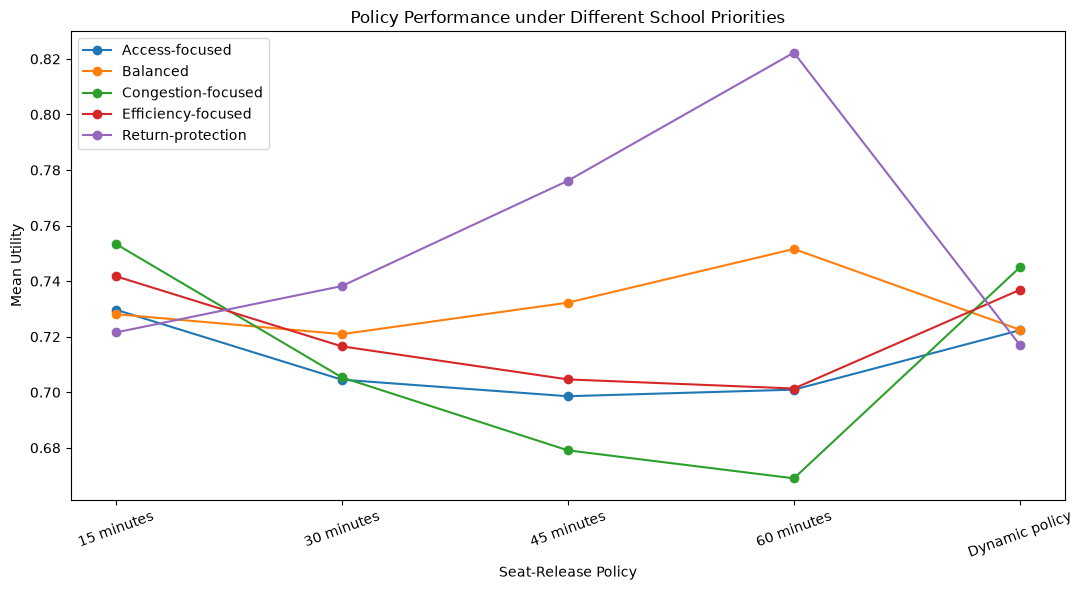

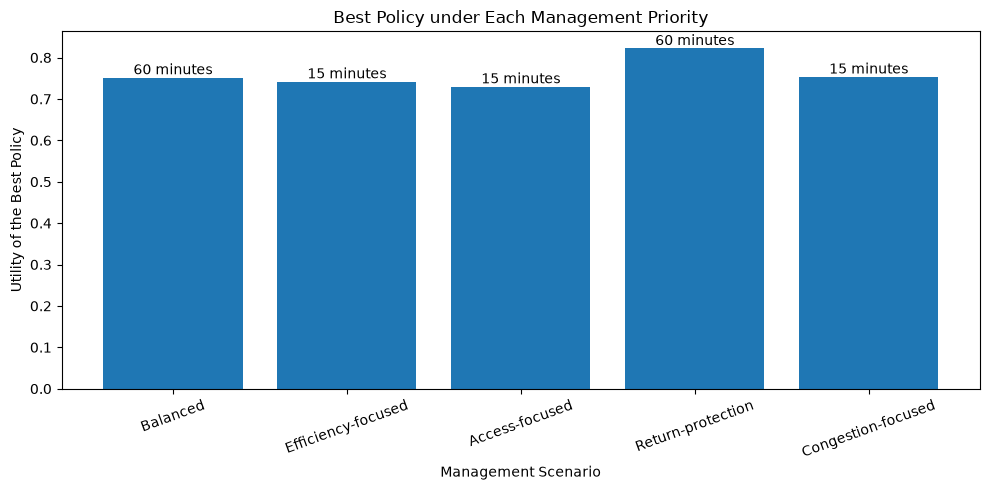

,scenario,rank,policy_name,mean_utility,is_optimal
0,Access-focused,1,15 minutes,0.729728,True
1,Access-focused,2,Dynamic policy,0.722338,False
2,Access-focused,3,30 minutes,0.704531,False
3,Access-focused,4,60 minutes,0.700942,False
4,Access-focused,5,45 minutes,0.698571,False
5,Balanced,1,60 minutes,0.751578,True
6,Balanced,2,45 minutes,0.732259,False
7,Balanced,3,15 minutes,0.728122,False
8,Balanced,4,Dynamic policy,0.722523,False
9,Balanced,5,30 minutes,0.720921,False


In [14]:
management_pivot = (
    management_sensitivity.pivot(
        index="policy_order",
        columns="scenario",
        values="mean_utility"
    )
    .sort_index()
)

plt.figure(figsize=(11, 6))
for scenario in management_pivot.columns:
    plt.plot(
        management_pivot.index,
        management_pivot[scenario],
        marker="o",
        label=scenario
    )

plt.xlabel("Seat-Release Policy")
plt.ylabel("Mean Utility")
plt.title("Policy Performance under Different School Priorities")
plt.xticks(
    range(len(POLICIES)),
    [POLICY_NAMES[p] for p in POLICIES],
    rotation=20
)
plt.legend()
plt.tight_layout()
plt.show()


scenario_order = list(MANAGEMENT_SCENARIOS)
optimal_plot = (
    optimal_by_management_priority
    .set_index("scenario")
    .loc[scenario_order]
    .reset_index()
)

plt.figure(figsize=(10, 5))
x = np.arange(len(optimal_plot))
plt.bar(x, optimal_plot["mean_utility"])
plt.xlabel("Management Scenario")
plt.ylabel("Utility of the Best Policy")
plt.title("Best Policy under Each Management Priority")
plt.xticks(x, optimal_plot["scenario"], rotation=20)

for index, row in optimal_plot.iterrows():
    plt.text(
        index,
        row["mean_utility"],
        row["policy_name"],
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


policy_ranking_by_scenario = (
    management_sensitivity
    .sort_values(
        ["scenario", "mean_utility"],
        ascending=[True, False]
    )
    .assign(
        rank=lambda data: data.groupby("scenario").cumcount() + 1
    )[
        [
            "scenario",
            "rank",
            "policy_name",
            "mean_utility",
            "is_optimal"
        ]
    ]
    .reset_index(drop=True)
)

policy_ranking_by_scenario


## Sensitivity to behavioral and demand assumptions

The next analysis changes one model assumption at a time while retaining the revised baseline utility. All five policies, including the dynamic policy, are compared.

Three uncertain assumptions are examined:

1. Arrival intensity
2. Temporary-leave probability
3. Maximum absence duration

In [15]:
def one_parameter_sensitivity(
    parameter_name,
    parameter_values,
    replications=20,
    base_seed=5000
):
    rows = []

    for value_index, value in enumerate(parameter_values):
        parameter_arguments = {parameter_name: value}

        scenario_results = compare_policies(
            replications=replications,
            base_seed=base_seed + 1000 * value_index,
            **parameter_arguments
        )

        scenario_summary = (
            scenario_results.groupby("policy")
            .agg(
                mean_utility=("baseline_utility", "mean"),
                mean_utilization=("productive_utilization", "mean"),
                mean_new_wait=("mean_new_waiting_time", "mean"),
                mean_new_wait_cost=("normalized_new_wait_cost", "mean"),
                mean_abandonment=("new_arrival_abandonment_rate", "mean"),
                mean_returning_wait_cost=("returning_wait_cost", "mean"),
                mean_service_welfare=("service_welfare", "mean"),
                mean_pressure_idle_externality=("pressure_idle_externality", "mean"),
                mean_displacement=("displacement_rate", "mean"),
                mean_reserved_unoccupied=("reserved_unoccupied_rate", "mean")
            )
            .reset_index()
        )

        scenario_summary["parameter"] = parameter_name
        scenario_summary["parameter_value"] = value

        best_policy = scenario_summary.loc[
            scenario_summary["mean_utility"].idxmax(),
            "policy"
        ]
        scenario_summary["is_optimal"] = (
            scenario_summary["policy"] == best_policy
        )

        rows.append(scenario_summary)

    return pd.concat(rows, ignore_index=True)

In [16]:

# These cells can take several minutes when the number of replications is large.

arrival_sensitivity = one_parameter_sensitivity(
    parameter_name="arrival_scale",
    parameter_values=[0.8, 1.0, 1.2],
    replications=20,
    base_seed=6000
)

leave_sensitivity = one_parameter_sensitivity(
    parameter_name="leave_probability",
    parameter_values=[0.001, 0.002, 0.004],
    replications=20,
    base_seed=9000
)

# Finer sweep to identify policy regions as absence duration changes
AWAY_MAX_VALUES = list(range(20, 100, 5))

absence_sensitivity = one_parameter_sensitivity(
    parameter_name="away_max",
    parameter_values=AWAY_MAX_VALUES,
    replications=20,
    base_seed=12000
)

parameter_sensitivity = pd.concat(
    [
        arrival_sensitivity,
        leave_sensitivity,
        absence_sensitivity
    ],
    ignore_index=True
)


In [17]:

optimal_parameter_policies = (
    parameter_sensitivity[
        parameter_sensitivity["is_optimal"]
    ][
        [
            "parameter",
            "parameter_value",
            "policy",
            "mean_utility"
        ]
    ]
    .sort_values(["parameter", "parameter_value"])
    .reset_index(drop=True)
)

optimal_parameter_policies


,parameter,parameter_value,policy,mean_utility
0,arrival_scale,0.800,15_min,0.842909
1,arrival_scale,1.000,15_min,0.738303
2,arrival_scale,1.200,15_min,0.601218
3,away_max,20.000,30_min,0.757235
4,away_max,25.000,30_min,0.753867
5,away_max,30.000,45_min,0.745945
6,away_max,35.000,45_min,0.737207
7,away_max,40.000,15_min,0.740734
8,away_max,45.000,15_min,0.731626
9,away_max,50.000,dynamic,0.735267



## Policy regions for maximum temporary-absence duration

This creates a policy map showing whether different absence-duration ranges favor different release thresholds.


In [18]:
away_policy_map = (
    parameter_sensitivity[
        (parameter_sensitivity["parameter"] == "away_max")
        & (parameter_sensitivity["is_optimal"])
    ][["parameter_value", "policy", "mean_utility"]]
    .rename(columns={
        "parameter_value": "away_max",
        "policy": "optimal_policy"
    })
    .sort_values("away_max")
    .reset_index(drop=True)
)

away_policy_map["optimal_policy_name"] = away_policy_map["optimal_policy"].map(POLICY_NAMES)
away_policy_map["policy_code"] = away_policy_map["optimal_policy"].map(POLICY_ORDER)
away_policy_map


,away_max,optimal_policy,mean_utility,optimal_policy_name,policy_code
0,20.0,30_min,0.757235,30 minutes,1
1,25.0,30_min,0.753867,30 minutes,1
2,30.0,45_min,0.745945,45 minutes,2
3,35.0,45_min,0.737207,45 minutes,2
4,40.0,15_min,0.740734,15 minutes,0
5,45.0,15_min,0.731626,15 minutes,0
6,50.0,dynamic,0.735267,Dynamic policy,4
7,55.0,15_min,0.734838,15 minutes,0
8,60.0,15_min,0.729221,15 minutes,0
9,65.0,15_min,0.733560,15 minutes,0


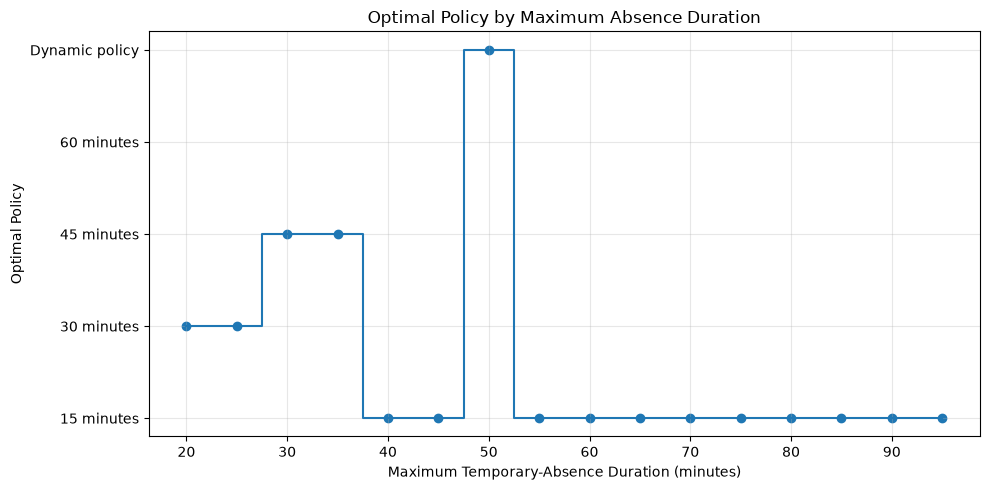

In [19]:
plt.figure(figsize=(10, 5))
plt.step(
    away_policy_map["away_max"],
    away_policy_map["policy_code"],
    where="mid"
)
plt.scatter(away_policy_map["away_max"], away_policy_map["policy_code"])
plt.xlabel("Maximum Temporary-Absence Duration (minutes)")
plt.ylabel("Optimal Policy")
plt.title("Optimal Policy by Maximum Absence Duration")
plt.yticks(range(len(POLICIES)), [POLICY_NAMES[p] for p in POLICIES])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
def summarize_policy_regions(policy_map):
    regions = []
    start_value = policy_map.loc[0, "away_max"]
    current_policy = policy_map.loc[0, "optimal_policy"]
    previous_value = start_value

    for i in range(1, len(policy_map)):
        value = policy_map.loc[i, "away_max"]
        policy = policy_map.loc[i, "optimal_policy"]

        if policy != current_policy:
            regions.append({
                "away_max_from": start_value,
                "away_max_to": previous_value,
                "optimal_policy": current_policy,
                "optimal_policy_name": POLICY_NAMES[current_policy]
            })
            start_value = value
            current_policy = policy
        previous_value = value

    regions.append({
        "away_max_from": start_value,
        "away_max_to": previous_value,
        "optimal_policy": current_policy,
        "optimal_policy_name": POLICY_NAMES[current_policy]
    })
    return pd.DataFrame(regions)


policy_regions = summarize_policy_regions(away_policy_map)
policy_regions


,away_max_from,away_max_to,optimal_policy,optimal_policy_name
0,20.0,25.0,30_min,30 minutes
1,30.0,35.0,45_min,45 minutes
2,40.0,45.0,15_min,15 minutes
3,50.0,50.0,dynamic,Dynamic policy
4,55.0,95.0,15_min,15 minutes


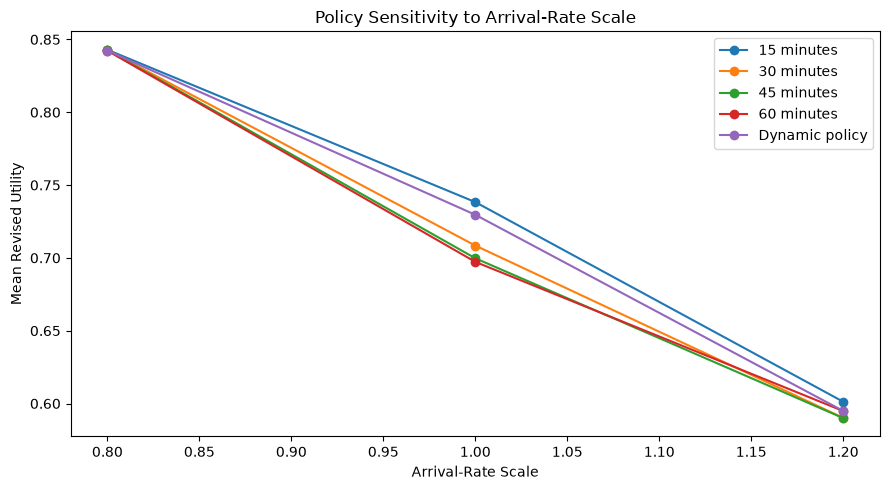

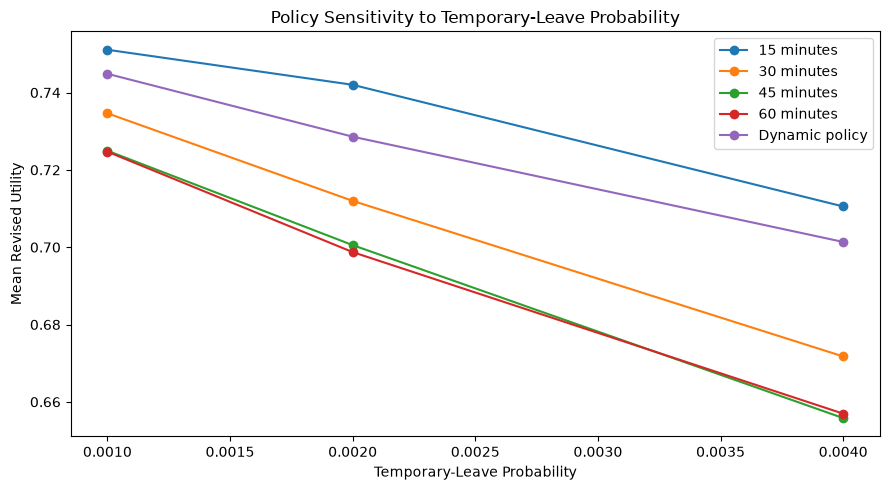

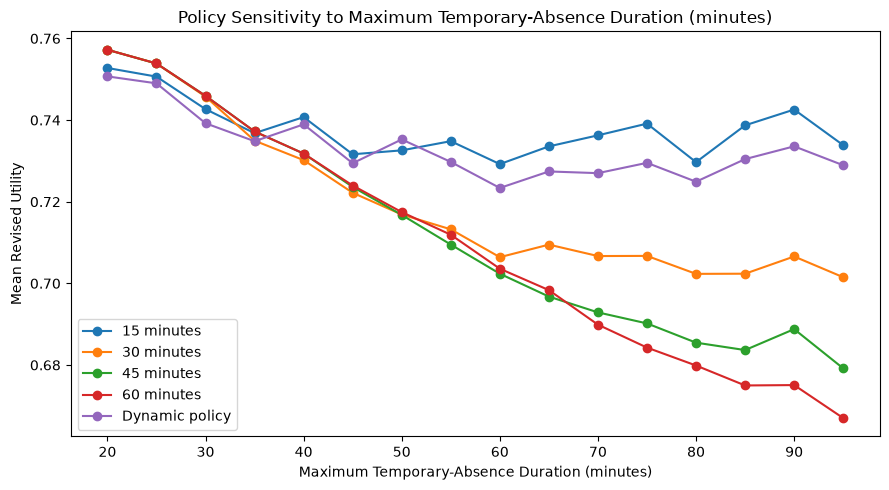

In [21]:

def plot_parameter_sensitivity(data, parameter_name, x_label):
    subset = data[data["parameter"] == parameter_name]

    plt.figure(figsize=(9, 5))

    for policy in POLICIES:
        policy_data = subset[
            subset["policy"] == policy
        ].sort_values("parameter_value")

        plt.plot(
            policy_data["parameter_value"],
            policy_data["mean_utility"],
            marker="o",
            label=POLICY_NAMES[policy]
        )

    plt.xlabel(x_label)
    plt.ylabel("Mean Revised Utility")
    plt.title(f"Policy Sensitivity to {x_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_parameter_sensitivity(
    parameter_sensitivity,
    "arrival_scale",
    "Arrival-Rate Scale"
)

plot_parameter_sensitivity(
    parameter_sensitivity,
    "leave_probability",
    "Temporary-Leave Probability"
)

plot_parameter_sensitivity(
    parameter_sensitivity,
    "away_max",
    "Maximum Temporary-Absence Duration (minutes)"
)


In [22]:
dynamic_threshold_diagnostic = pd.DataFrame({
    "Threshold": [15, 30, 45, 60],
    "Share": [
        policy_summary.loc["dynamic", "share_threshold_15"],
        policy_summary.loc["dynamic", "share_threshold_30"],
        policy_summary.loc["dynamic", "share_threshold_45"],
        policy_summary.loc["dynamic", "share_threshold_60"]
    ]
})

dynamic_threshold_diagnostic


,Threshold,Share
0,15,0.577097
1,30,0.041662
2,45,0.076081
3,60,0.305160
